In [2]:
import json
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt

### JSON reading and binarization of the labels (none, implicit)

In [3]:

path_json = "/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Cours/Python avancé/Data/enthymemes_2/merged_annotations_v2.json"

with open(path_json, "r", encoding="utf-8") as f:
    data = json.load(f)

tweets = []
labels = []

for entry in data:
    label_bin = "none" if entry["majority_label"] == "none" else "implicit"
    tweets.append(entry["tweet_text"])
    labels.append(label_bin)

tweets_array = np.array(tweets)
y = np.array(labels)

print(f"Totale esempi: {len(tweets_array)}")
print(f"Distribuzione: none={np.sum(y=='none')}, implicit={np.sum(y=='implicit')}")

Totale esempi: 1333
Distribuzione: none=882, implicit=451


### Tweets Encoding

In [4]:
from sentence_transformers import SentenceTransformer

model_name = "sentence-transformers/all-mpnet-base-v2"
encoder = SentenceTransformer(model_name)

# tweets è la lista Python già creata nella cella di caricamento del JSON
tweets_array = np.array(tweets)  # conversione necessaria per indicizzare con gli split

print(f"Encoding di {len(tweets_array)} tweet...")
embeddings = encoder.encode(tweets_array, show_progress_bar=True, batch_size=32)

print(f"Shape embeddings: {embeddings.shape}")  # atteso: (1333, 768)

/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0).
W0517 20:16:59.885000 19739 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2316.79it/s, Materializing param=pooler.dense.weight]                        
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-

Encoding di 1333 tweet...


Batches: 100%|██████████| 42/42 [00:09<00:00,  4.62it/s]

Shape embeddings: (1333, 768)


### Embeddings split

In [5]:
emb_train, emb_temp, y_train, y_temp = train_test_split(
    embeddings, y, test_size=0.3, random_state=42, stratify=y
)
emb_test, emb_validation, y_test, y_validation = train_test_split(
    emb_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train:      {emb_train.shape[0]} esempi  (none={np.sum(y_train=='none')}, implicit={np.sum(y_train=='implicit')})")
print(f"Test:       {emb_test.shape[0]} esempi  (none={np.sum(y_test=='none')}, implicit={np.sum(y_test=='implicit')})")
print(f"Validation: {emb_validation.shape[0]} esempi  (none={np.sum(y_validation=='none')}, implicit={np.sum(y_validation=='implicit')})")

Train:      933 esempi  (none=617, implicit=316)
Test:       200 esempi  (none=133, implicit=67)
Validation: 200 esempi  (none=132, implicit=68)


### Normalization

In [6]:
scaler = StandardScaler()
emb_train_scaled = scaler.fit_transform(emb_train)
emb_test_scaled  = scaler.transform(emb_test)
emb_val_scaled   = scaler.transform(emb_validation)

### Grid search with SVM

In [7]:
param_grid = {'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

grid_emb = GridSearchCV(
    LinearSVC(max_iter=5000, random_state=42, class_weight='balanced'),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid_emb.fit(emb_train_scaled, y_train)

print(f"Miglior C:           {grid_emb.best_params_['C']}")
print(f"Miglior F1 macro CV: {grid_emb.best_score_:.4f}")

best_svc = grid_emb.best_estimator_

Fitting 5 folds for each of 6 candidates, totalling 30 fits


/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/Users/deniseatzori/miniconda3/envs/pythonAv/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/Users/deniseatzori/miniconda3/envs/

Miglior C:           0.01
Miglior F1 macro CV: 0.5874


In [8]:
print("=== Validation set ===")
val_preds = best_svc.predict(emb_val_scaled)
print(classification_report(y_validation, val_preds, zero_division=0))

print("=== Test set ===")
test_preds = best_svc.predict(emb_test_scaled)
print(classification_report(y_test, test_preds, zero_division=0))

=== Validation set ===
              precision    recall  f1-score   support

    implicit       0.52      0.53      0.53        68
        none       0.76      0.75      0.75       132

    accuracy                           0.68       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.68      0.68      0.68       200

=== Test set ===
              precision    recall  f1-score   support

    implicit       0.45      0.55      0.49        67
        none       0.74      0.65      0.70       133

    accuracy                           0.62       200
   macro avg       0.59      0.60      0.59       200
weighted avg       0.64      0.62      0.63       200



### Optimal treshold with calibrated model

In [9]:
calibrated_svc = CalibratedClassifierCV(
    LinearSVC(C=grid_emb.best_params_['C'], max_iter=5000, random_state=42, class_weight='balanced'),
    cv=5
)
calibrated_svc.fit(emb_train_scaled, y_train)

from sklearn.metrics import precision_recall_curve

proba_val = calibrated_svc.predict_proba(emb_val_scaled)
idx_implicit = list(calibrated_svc.classes_).index('implicit')
scores_val = proba_val[:, idx_implicit]

precisions, recalls, soglie = precision_recall_curve(y_validation, scores_val, pos_label='implicit')
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx   = np.argmax(f1_scores)
best_soglia = soglie[best_idx]

print(f"Soglia ottimale (su validation): {best_soglia:.4f}")

# Applica al test set
proba_test = calibrated_svc.predict_proba(emb_test_scaled)
test_preds_opt = np.where(proba_test[:, idx_implicit] >= best_soglia, 'implicit', 'none')
print("\n=== Test set con soglia ottimizzata ===")
print(classification_report(y_test, test_preds_opt, zero_division=0))

Soglia ottimale (su validation): 0.3327

=== Test set con soglia ottimizzata ===
              precision    recall  f1-score   support

    implicit       0.39      0.61      0.48        67
        none       0.73      0.53      0.61       133

    accuracy                           0.56       200
   macro avg       0.56      0.57      0.55       200
weighted avg       0.62      0.56      0.57       200



#### Features importance

In [10]:
# Esempi più "tipicamente implicit" e più "tipicamente none" secondo il modello
decision_scores = best_svc.decision_function(emb_test_scaled)

top_implicit_idx = np.argsort(decision_scores)[-5:][::-1]
top_none_idx     = np.argsort(decision_scores)[:5]

print("=== Tweet classificati con più confidenza come IMPLICIT ===")
for i in top_implicit_idx:
    print(f"  [{decision_scores[i]:+.3f}] {tweets_array[i][:120]}")  # tronca a 120 char

print("\n=== Tweet classificati con più confidenza come NONE ===")
for i in top_none_idx:
    print(f"  [{decision_scores[i]:+.3f}] {tweets_array[i][:120]}")

=== Tweet classificati con più confidenza come IMPLICIT ===
  [+3.436] Reagan was great, but every President makes a monumental mistake somewhere along the way. This was it with Reagan?? Once
  [+3.084] NY Post: Children, who ordinarily love shots, recoil in pain and horror from vaccine mandate forced on them by parents.
  [+3.072] Pfizer's two omicron-focused booster vaccines massively improve a person's immune response against the COVID variant, th
  [+2.926] I love how the left is babbling about womens rights after forcing an experimental vaccine on everyone then bring up Jan 
  [+2.869] Hearings. Vaccines not doing what we were told.

=== Tweet classificati con più confidenza come NONE ===
  [-2.202] Saving the Tassie devil: COVID-19 vaccine technology gives researchers hope of success | ABC News
  [-2.074] so the Pentagon can just ignore federal laws, but individuals in the armed forces can't ignore vaccine mandates?
  [-2.021] Why is nobody doing a deep investigation to uncover t

## Kernel comparison using cross-validation

In [11]:
from sklearn.svm import SVC  # nota: SVC, non LinearSVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report
import pandas as pd

# Configurazioni da testare
kernel_configs = {
    'rbf':    {'kernel': ['rbf'],    'C': [0.1, 1.0, 5.0, 10.0], 'gamma': ['scale', 'auto', 0.001, 0.01]},
    'poly':   {'kernel': ['poly'],   'C': [0.1, 1.0, 5.0],        'degree': [2, 3],   'gamma': ['scale']},
    'sigmoid':{'kernel': ['sigmoid'],'C': [0.1, 1.0, 5.0],        'gamma': ['scale', 'auto']},
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
risultati_kernel = {}

for nome, params in kernel_configs.items():
    print(f"Grid search kernel={nome}...")
    grid = GridSearchCV(
        SVC(class_weight='balanced', random_state=42),
        params,
        cv=cv,
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    grid.fit(emb_train_scaled, y_train)
    risultati_kernel[nome] = {
        'best_params': grid.best_params_,
        'cv_f1_macro': grid.best_score_,
        'model':       grid.best_estimator_
    }
    print(f"  → miglior F1 macro CV: {grid.best_score_:.4f}  |  params: {grid.best_params_}")

# Aggiungi anche il lineare per confronto diretto
risultati_kernel['linear'] = {
    'best_params': grid_emb.best_params_,
    'cv_f1_macro': grid_emb.best_score_,
    'model':       best_svc
}

Grid search kernel=rbf...
  → miglior F1 macro CV: 0.6430  |  params: {'C': 1.0, 'gamma': 0.001, 'kernel': 'rbf'}
Grid search kernel=poly...
  → miglior F1 macro CV: 0.5813  |  params: {'C': 1.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
Grid search kernel=sigmoid...
  → miglior F1 macro CV: 0.6150  |  params: {'C': 1.0, 'gamma': 'scale', 'kernel': 'sigmoid'}


In [12]:
# Test results for all kernels

rows = []

for nome, info in risultati_kernel.items():
    model = info['model']
    
    # LinearSVC non ha predict con SVC interface, gestisci separatamente
    if nome == 'linear':
        preds = model.predict(emb_test_scaled)
    else:
        preds = model.predict(emb_test_scaled)
    
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    rows.append({
        'kernel':             nome,
        'cv_f1_macro':        round(info['cv_f1_macro'], 4),
        'test_f1_macro':      round(report['macro avg']['f1-score'], 4),
        'implicit_precision': round(report['implicit']['precision'], 4),
        'implicit_recall':    round(report['implicit']['recall'], 4),
        'implicit_f1':        round(report['implicit']['f1-score'], 4),
        'none_f1':            round(report['none']['f1-score'], 4),
        'best_params':        info['best_params']
    })

df_risultati = pd.DataFrame(rows).sort_values('test_f1_macro', ascending=False)
print(df_risultati.to_string(index=False))

 kernel  cv_f1_macro  test_f1_macro  implicit_precision  implicit_recall  implicit_f1  none_f1                                                 best_params
    rbf       0.6430         0.6631              0.5244           0.6418       0.5772   0.7490                 {'C': 1.0, 'gamma': 0.001, 'kernel': 'rbf'}
   poly       0.5813         0.6002              0.4595           0.5075       0.4823   0.7181 {'C': 1.0, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}
 linear       0.5874         0.5947              0.4458           0.5522       0.4933   0.6960                                                 {'C': 0.01}
sigmoid       0.6150         0.5894              0.4362           0.6119       0.5093   0.6695           {'C': 1.0, 'gamma': 'scale', 'kernel': 'sigmoid'}


In [13]:
best_row  = df_risultati.iloc[0]
best_nome = best_row['kernel']
best_model = risultati_kernel[best_nome]['model']

print(f"=== Miglior kernel: {best_nome} ===")
print(f"Parametri: {best_row['best_params']}\n")

print("--- Validation set ---")
val_preds_best = best_model.predict(emb_val_scaled)
print(classification_report(y_validation, val_preds_best, zero_division=0))

print("--- Test set ---")
test_preds_best = best_model.predict(emb_test_scaled)
print(classification_report(y_test, test_preds_best, zero_division=0))

=== Miglior kernel: rbf ===
Parametri: {'C': 1.0, 'gamma': 0.001, 'kernel': 'rbf'}

--- Validation set ---
              precision    recall  f1-score   support

    implicit       0.51      0.59      0.54        68
        none       0.77      0.70      0.74       132

    accuracy                           0.67       200
   macro avg       0.64      0.65      0.64       200
weighted avg       0.68      0.67      0.67       200

--- Test set ---
              precision    recall  f1-score   support

    implicit       0.52      0.64      0.58        67
        none       0.80      0.71      0.75       133

    accuracy                           0.69       200
   macro avg       0.66      0.67      0.66       200
weighted avg       0.71      0.69      0.69       200



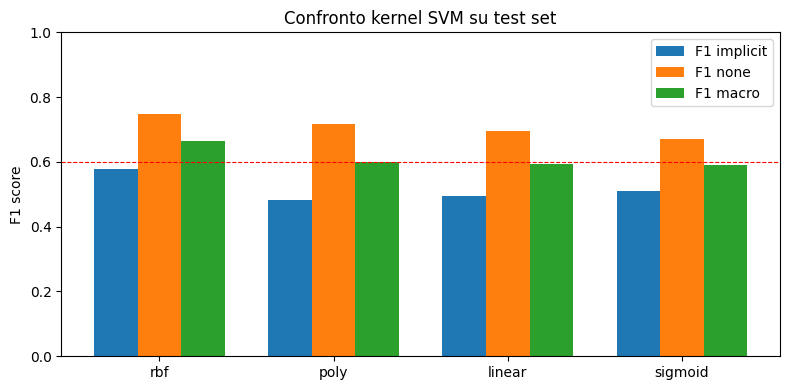

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))

kernel_names = df_risultati['kernel'].tolist()
x = np.arange(len(kernel_names))
width = 0.25

ax.bar(x - width, df_risultati['implicit_f1'],  width, label='F1 implicit')
ax.bar(x,         df_risultati['none_f1'],       width, label='F1 none')
ax.bar(x + width, df_risultati['test_f1_macro'], width, label='F1 macro')

ax.set_xticks(x)
ax.set_xticklabels(kernel_names)
ax.set_ylim(0, 1)
ax.set_ylabel('F1 score')
ax.set_title('Confronto kernel SVM su test set')
ax.legend()
ax.axhline(0.60, color='red', linestyle='--', linewidth=0.8, label='baseline lineare')
plt.tight_layout()
plt.show()